# MIE1517 Final Project – Detecting AI-Generated Images (CIFAKE) with Vision Transformers
####  by Lawrence Han, Sally Zhao, Max Li, Xi Chen


In this project we build an image classifier to detect whether an image is a **real** CIFAR-10 photo or an **AI-generated** synthetic image using the CIFAKE dataset. Using transfer learning with a pre-trained Vision Transformer (ViT-B/16) and hyperparameter tuning, our best model achieves about **96–97% accuracy** on a held-out test set (precision 96.8%, recall 96.4%, F1 score 96.6). These results show that Vision Transformers can reliably distinguish AI-generated images from real ones in this setting, which is useful for improving trust and safety in online visual content.


Link to this notebook on Google Colab: https://colab.research.google.com/drive/1hBRxhpR15tpp-tuOYWhFlVVVxFKD4qsA#scrollTo=2A50U3TlNf-R

## Part 1. Project Overview

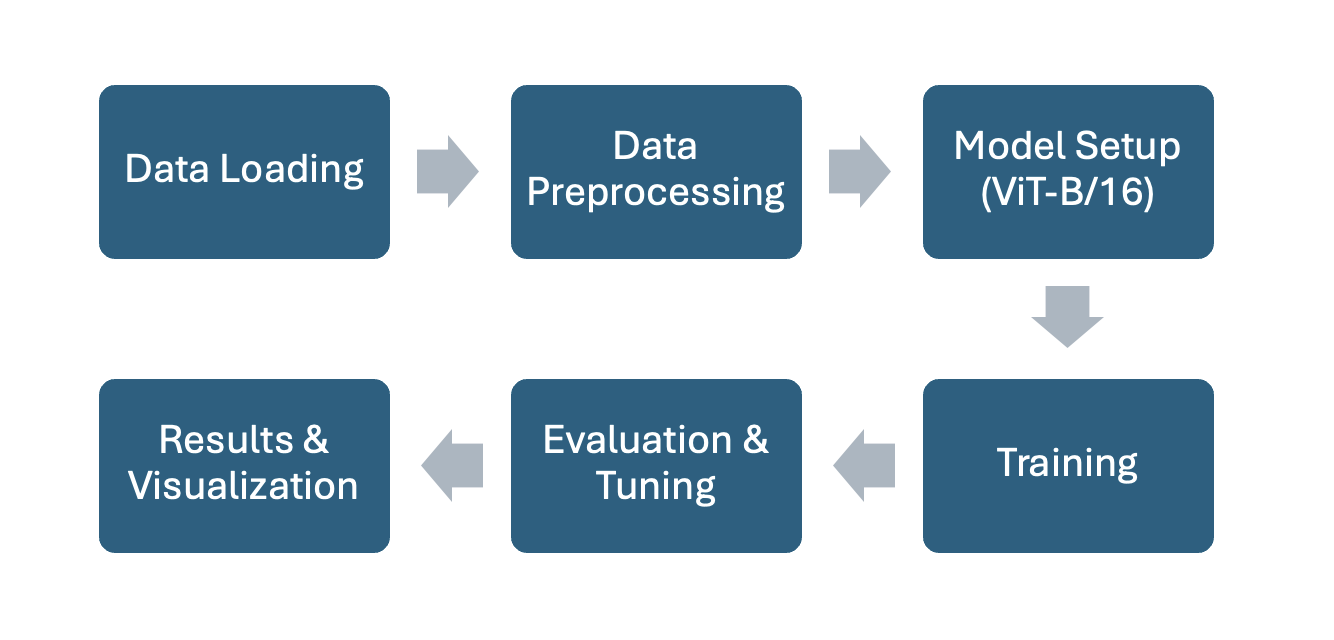

This figure shows the end-to-end workflow of our project, from loading and preprocessing the CIFAKE data to fine-tuning the ViT model and evaluating its performance on detecting AI-generated images.

### 1. Motivation

Generative models such as Stable Diffusion can create **photorealistic images** that are difficult for humans to distinguish from real photos.  
This raises concerns for **misinformation, deepfakes, and trust** in online images.  
Our goal is to train a model that can automatically classify an image as:

- **REAL** – original image from CIFAR-10  
- **FAKE** – AI-generated synthetic image designed to look like CIFAR-10

### 2. The CIFAKE Dataset (Bird & Lotfi, 2023)

We use the **CIFAKE: Real and AI-Generated Synthetic Images** dataset from Kaggle.  
Key properties (based on the dataset description and original paper):

- 120,000 images in total (32×32 colour images)
- 60,000 **REAL** images from CIFAR-10
- 60,000 **FAKE** images generated with Stable Diffusion v1.4
- Binary label: `0 = REAL`, `1 = FAKE`

In this notebook we resize the 32×32 images to 224×224 and use them to fine‑tune a **Vision Transformer (ViT-B/16)** for binary classification.

Link to the data: https://www.kaggle.com/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images

### 3. Model Description

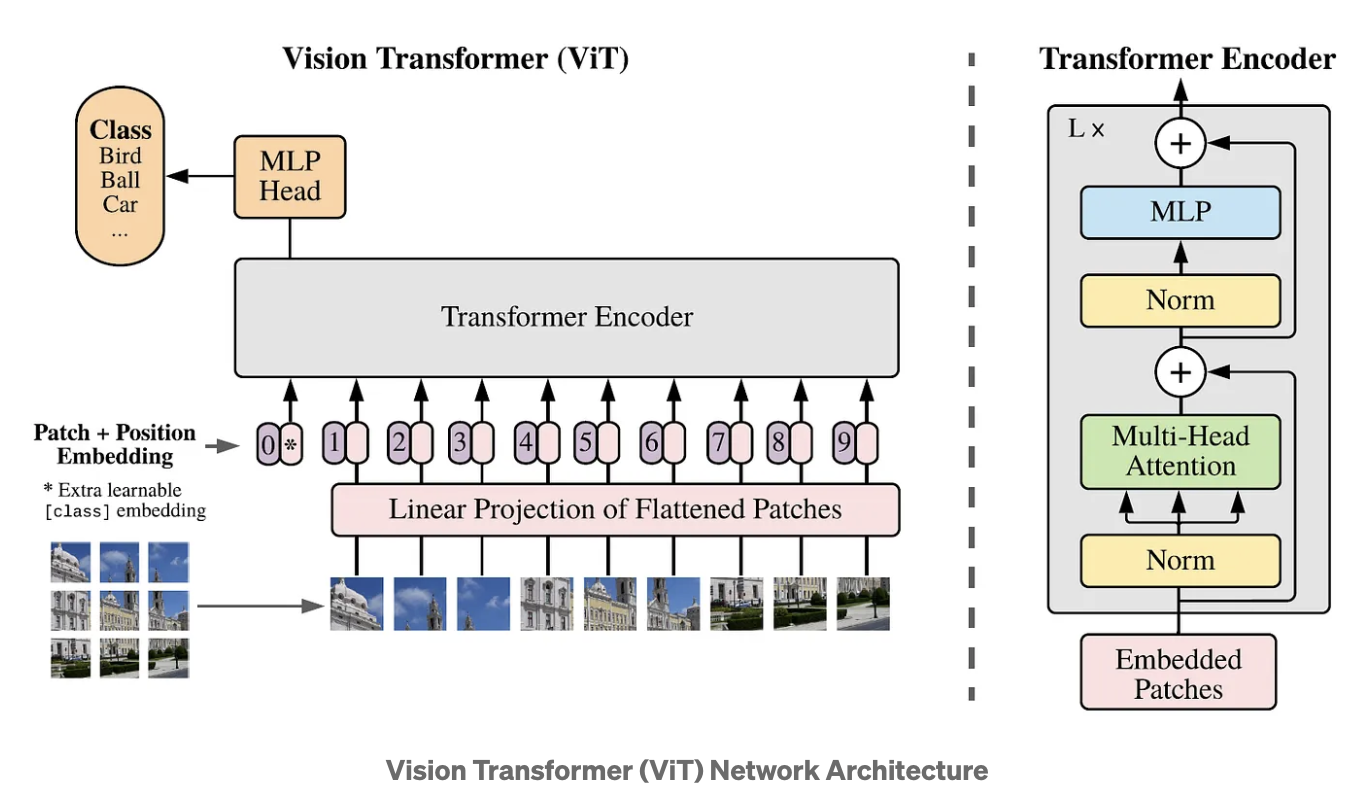

We use a Vision Transformer (ViT-B/16) as the base model. It was first pre-trained on a large image dataset (ImageNet), so it has already learned general visual patterns such as edges, textures, and shapes. In this project, we keep these learned features and only fine-tune the final layers on our two classes (real vs AI-generated images). This transfer learning approach lets us train an accurate classifier with limited data and compute, while taking advantage of a powerful pre-trained model.


### 4. A Deeper Dive into the Vision Transformer (ViT) Models

The Vision Transformer (ViT) is a deep learning model that applies the Transformer architecture (originally designed for text) to images. Instead of scanning the image with convolution filters like a CNN, ViT **cuts the image into patches**, treats each patch like a “token,” and then processes these tokens with self-attention.

#### 1) From image to patches (tokens)

Our model, **ViT-B/16**, works with fixed-size image patches:

- The input image is split into small patches of size **16×16** pixels (the “/16” in the name).
- Each patch is flattened into a vector and passed through a linear layer to create a **patch embedding**.
- A special **[CLS] token** is added to the sequence; this token will later represent the whole image.
- **Position embeddings** are added so the model knows where each patch is located in the original image.

At this point, the image has become a sequence of tokens, similar to words in a sentence.

#### 2) Transformer encoder with self-attention

The sequence of tokens is then processed by several **Transformer encoder blocks**. Each block has two main parts:

- **Multi-Head Self-Attention:**  
  Every patch can “look at” all other patches and decide which ones are important. This helps the model capture global relationships, such as how different regions of the image relate to each other.

- **Feed-Forward Network (MLP):**  
  After attention, each token is passed through a small neural network to transform the features further.

Layer normalization and residual connections help keep training stable and make the model deeper and more expressive.

#### 3) Classification head and fine-tuning

After passing through all Transformer blocks, we take the final representation of the **[CLS] token** as a summary of the entire image. This vector is fed into a small **classification head** (a few fully connected layers) that outputs a single logit for our **binary task** (real vs AI-generated).

In this project, we use a **pre-trained ViT-B/16** (trained on ImageNet) and then:

- Keep the pre-trained backbone weights as a strong starting point.
- Replace and fine-tune the final layers on our CIFAKE dataset (two classes).

This **transfer learning** approach lets us leverage powerful pre-trained visual features while adapting the model to our specific task.

#### 4) Why ViT is suitable for detecting AI-generated images

ViT is especially helpful here because:

- Self-attention can capture **global patterns** and subtle inconsistencies across the whole image.
- Patch-based processing makes it easier to focus on **fine-grained textures and artifacts** that may appear in synthetic images.
- Pre-training on large datasets provides strong general visual understanding, which improves performance even with a limited task-specific dataset.

Together, these properties help our ViT model effectively distinguish **real** images from **AI-generated** ones.


### 5. Loss Function We Optimized

For training our classifier, we optimize the **binary cross-entropy loss** (implemented as `BCEWithLogitsLoss` in PyTorch).

Our model outputs a single real-valued score for each image. After applying a sigmoid function, this score can be interpreted as the **predicted probability** that the image is AI-generated (class = 1). The binary cross-entropy loss then:

- **Penalizes wrong confident predictions** (for example, predicting a high probability for AI-generated when the image is actually real).
- **Rewards correct confident predictions** (high probability for the true class).

For each image, the loss compares the predicted probability \(\hat{p}\) with the true label \(y \in \{0, 1\}\). The total loss is the **average** over the mini-batch. During training, gradient descent updates the model weights to **minimize** this loss, which leads to better predictions and higher accuracy on the real vs AI-generated classification task.


## Part 2. Our Code and Detailed Process

### 1. Load and clean data

In [ ]:
_ = !pip install kagglehub
_ = !pip install optuna

In [ ]:
# download data
import kagglehub

# Download latest version
path = kagglehub.dataset_download("birdy654/cifake-real-and-ai-generated-synthetic-images")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'cifake-real-and-ai-generated-synthetic-images' dataset.
Path to dataset files: /kaggle/input/cifake-real-and-ai-generated-synthetic-images


In [ ]:
import torch
import torch.nn as nn
from torchvision import models, datasets, transforms
from torch.utils.data import DataLoader, Subset, random_split, TensorDataset
from torch.amp import autocast, GradScaler
import optuna
from tqdm import tqdm
import gc
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import os
import random

In [ ]:
# lambda lab data dir
data_root = "/home/ubuntu/.cache/kagglehub/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images/versions/3"

# google colab data dir
data_root = "/kaggle/input/cifake-real-and-ai-generated-synthetic-images"

# imagenet stats
mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]

# data split
train_size = 7000
valid_size = 1500
test_size = 1500

# global seed
seed = 123

# temporary dropout rate (will fine tune during hyperparamter optimization)
dropout_rate = 0.1

In [ ]:
# transfer learning base model initialization
vit_model = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)
vit_model.heads.head = nn.Sequential(
        nn.Dropout(dropout_rate),
        nn.Linear(vit_model.heads.head.in_features, 1)
    )

In [ ]:
# function for reproducibility
def set_seed(seed=seed):
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True)

    # use deteministic matrix calculation in CUBLAS
    # specified in https://docs.nvidia.com/cuda/cublas/
    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

# set deterministic workers for high num_workers
def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

In [ ]:
# data loading
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

full_dataset = datasets.ImageFolder(data_root + "/train", transform=transform)

# fixed generator for reproducibility
g = torch.Generator().manual_seed(seed)

train_dataset, valid_dataset, test_dataset, others = random_split(
    full_dataset,
    [train_size, valid_size, test_size, len(full_dataset) - (train_size + valid_size + test_size)],
    generator=g
)

print("Number of training images:", len(train_dataset))
print("Number of validation images:", len(valid_dataset))
print("Number of testing images:", len(test_dataset))

Number of training images: 7000
Number of validation images: 1500
Number of testing images: 1500


**We have 7,000 training images, 1,500 validation images, and 1,500 testing images.**

#### Quick look at the CIFAKE dataset


Before diving into models, it is helpful to **visualize a few samples** from the training set to build intuition about what the model sees.

Class to index mapping: {'FAKE': 0, 'REAL': 1}


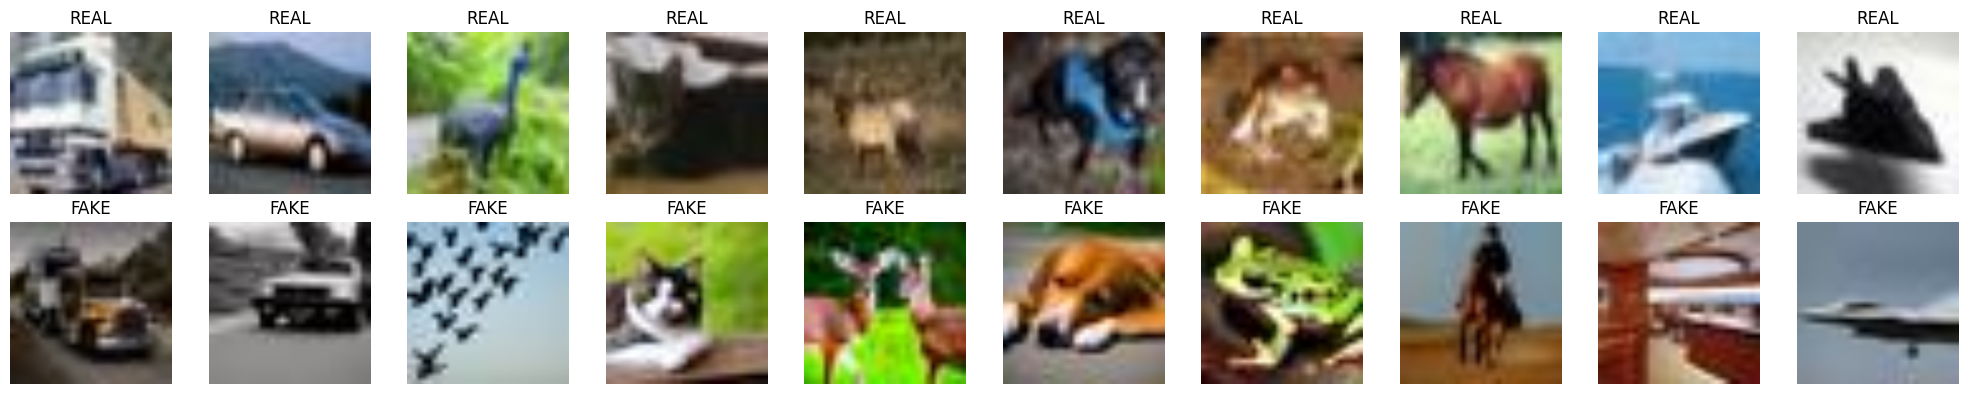

In [ ]:
import matplotlib.pyplot as plt
import torch

print("Class to index mapping:", full_dataset.class_to_idx)

# use the explicit mapping
fake_label = full_dataset.class_to_idx['FAKE']
real_label = full_dataset.class_to_idx['REAL']

# collect 10 real and 10 fake images
real_imgs, fake_imgs = [], []
for img, label in full_dataset:
    if label == real_label and len(real_imgs) < 10:
        real_imgs.append(img)
    elif label == fake_label and len(fake_imgs) < 10:
        fake_imgs.append(img)
    if len(real_imgs) == 10 and len(fake_imgs) == 10:
        break

# helper to undo normalization for plotting
def unnormalize(img_tensor):
    img = img_tensor.clone().detach().cpu()
    mean_t = torch.tensor(mean).view(3, 1, 1)
    std_t = torch.tensor(std).view(3, 1, 1)
    img = img * std_t + mean_t
    img = img.clamp(0, 1)
    return img

# plot 10 real (top row) and 10 fake (bottom row)
fig, axes = plt.subplots(2, 10, figsize=(20, 4))

for i in range(10):
    # real images row
    axes[0, i].imshow(unnormalize(real_imgs[i]).permute(1, 2, 0))
    axes[0, i].set_title("REAL")
    axes[0, i].axis("off")

    # fake images row
    axes[1, i].imshow(unnormalize(fake_imgs[i]).permute(1, 2, 0))
    axes[1, i].set_title("FAKE")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()


### 2. Define training and testing structure

In [ ]:
# get accuracy
def get_accuracy(model, data_loader):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, labels in tqdm(data_loader, desc=f"Computing accuracy", unit="batch", leave=False):
            inputs, labels = inputs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            outputs = model(inputs)
            probs = torch.sigmoid(outputs)
            predicted = torch.round(probs).squeeze()
            total += labels.shape[0]
            correct += (predicted == labels).sum().item()
    return correct / total

In [ ]:
# training function
def train(
        model,
        train_loader,
        valid_loader,
        lr,
        weight_decay,
        eta_min,
        num_epochs,
        batch_size,
        trial=None,
        verbose=True,
        save=None
        ):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=eta_min)

    if torch.cuda.is_available():
        scaler = GradScaler('cuda')

    train_loss, valid_accuracy = [], []

    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0

        for inputs, labels in tqdm(train_loader, desc=f"Training epoch {epoch+1}/{num_epochs}", unit="batch", leave=False):
            inputs, labels = inputs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            optimizer.zero_grad()

            # gpu training
            if torch.cuda.is_available():
                with autocast('cuda'):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels.unsqueeze(1).float())
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

            # cpu training
            else:
                outputs = model(inputs)
                loss = criterion(outputs, labels.unsqueeze(1).float())
                loss.backward()
                optimizer.step()

            epoch_loss += loss.item() * inputs.shape[0]

        # update learning rate
        scheduler.step()

        train_loss.append(epoch_loss / len(train_loader.dataset))
        valid_acc = get_accuracy(model, valid_loader)
        valid_accuracy.append(valid_acc)

        if verbose:
            print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss[-1]:.6f}, Valid Acc: {valid_acc:.6f}")

        if trial is not None:
            trial.report(valid_acc, epoch)

            if trial.should_prune():
                raise optuna.TrialPruned()

        if save:
            torch.save(model.state_dict(), save + str(epoch))

    result = {
        'train_loss': train_loss,
        'valid_accuracy': valid_accuracy,
        'max_valid_accuracy': max(valid_accuracy),
        'best epoch': valid_accuracy.index(max(valid_accuracy))
    }

    return result

### 3. Training and hyperparameter tuning

In [ ]:
# hyperparameter tuning
all_result = []

def objective(trial):
    lr = trial.suggest_float("lr", 1e-6, 1e-3, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64, 128])
    dropout_rate = trial.suggest_categorical("dropout_rate", [0.1, 0.2, 0.3, 0.4, 0.5])

    # for reproducibility
    set_seed(seed)
    g = torch.Generator()
    g.manual_seed(seed)

    # reinitialize dataloader of current batch_size
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        num_workers=32,
        shuffle=True, # shuffle for train for better generalization
        pin_memory=True,
        persistent_workers=True,
        prefetch_factor=8,
        generator=g,
        worker_init_fn=seed_worker)

    valid_loader = DataLoader(
        valid_dataset,
        batch_size=batch_size,
        num_workers=16,
        shuffle=False, # no shuffle for valid to ensure fair comparison
        pin_memory=True,
        prefetch_factor=8,
        generator=g,
        worker_init_fn=seed_worker)

    # reinitialize model instance
    vit_model = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)
    vit_model.heads.head = nn.Sequential(
        nn.Dropout(dropout_rate),
        nn.Linear(vit_model.heads.head.in_features, 1)
    )

    # train model
    result = train(
        vit_model,
        train_loader,
        valid_loader,
        lr=lr,
        weight_decay=weight_decay,
        eta_min=1e-6,
        num_epochs=10,
        batch_size=batch_size,
        trial=trial,
        verbose=False)

    # add result for plotting
    all_result.append(result)

    # clean up memory
    del vit_model
    del train_loader
    del valid_loader
    gc.collect()
    torch.cuda.empty_cache()

    return result['max_valid_accuracy']

# skip pruning for the first 5 trials
# prune after epoch 4 with step 1
pruner = optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=5, interval_steps=1)

# reproducible tree-structured parzen estimator sampler
sampler = optuna.samplers.TPESampler(seed=seed)

study = optuna.create_study(
    storage="sqlite:///./vit.db",
    direction="maximize",
    pruner=pruner,
    sampler=sampler)

# start optimization
study.optimize(objective, n_trials=50, gc_after_trial=True)

print(study.best_trial)

In [ ]:
# save all results for plotting and analysis
torch.save(all_result, "all_result.pt")

In [ ]:
# hyperparamter optimization analysis
study = optuna.load_study(
    study_name="no-name-6e38600e-3f92-4627-9a75-0f066b7fcbe8",
    storage="sqlite:///./vit.db"
)

from optuna.visualization import plot_param_importances
plot_param_importances(study).show()

from optuna.visualization import plot_optimization_history
plot_optimization_history(study).show()

from optuna.visualization import plot_parallel_coordinate
plot_parallel_coordinate(study).show()

from optuna.visualization import plot_slice
plot_slice(study).show()

from optuna.visualization import plot_contour
plot_contour(study).show()

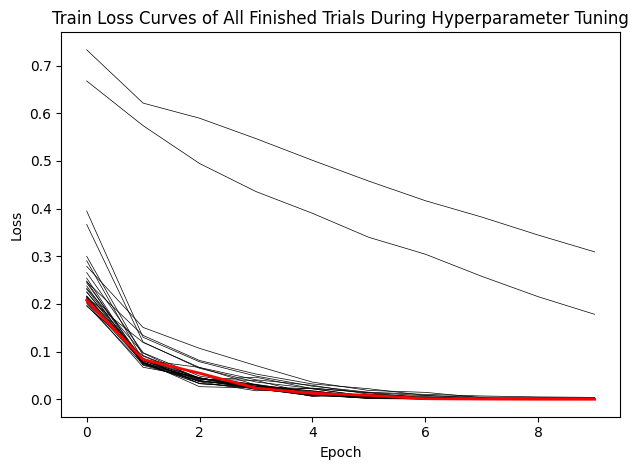

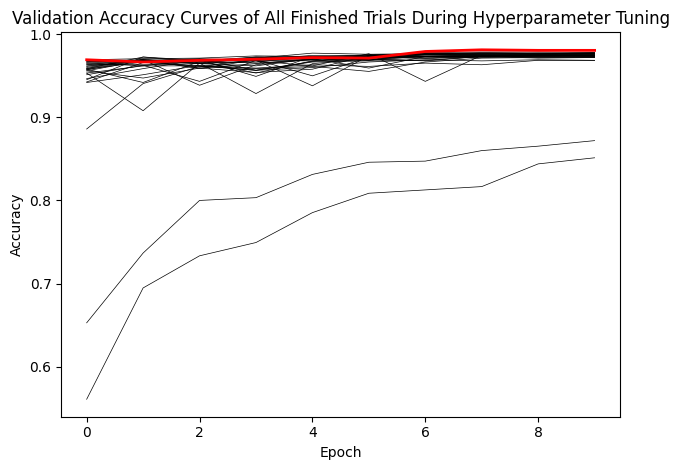

In [ ]:
# plot all completed trials
all_result = torch.load("all_result.pt")

# graph training loss curves
best_acc = max(r['max_valid_accuracy'] for r in all_result)

for r in all_result:
    if r['max_valid_accuracy'] != best_acc:
        plt.plot(r['train_loss'], linewidth=0.5, color='black')
    else:
        best_r = r
plt.plot(best_r['train_loss'], linewidth=2, color='red')

plt.title("Train Loss Curves of All Finished Trials During Hyperparameter Tuning")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.tight_layout()
plt.show()

# graph valid accuracy curves
for r in all_result:
    if r['max_valid_accuracy'] != best_acc:
        plt.plot(r['valid_accuracy'], linewidth=0.5, color='black')
    else:
        best_r = r
plt.plot(best_r['valid_accuracy'], linewidth=2, color='red')

plt.title("Validation Accuracy Curves of All Finished Trials During Hyperparameter Tuning")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.tight_layout()
plt.show()

### 4. Train final ViT model with best hyperparameters and get test result

We now:

1. Load the Optuna study created during hyperparameter search.  
2. Extract the best hyperparameters.  
3. Re‑train a **final ViT model** on the same train/validation split using these hyperparameters.  
4. Evaluate the model on the **held‑out test set** and report accuracy and other metrics.

In [ ]:
# train final model
best_params={
    'lr': 1.9612621021312128e-05,
    'weight_decay': 1.7581971969642436e-05,
    'batch_size': 16,
    'dropout_rate': 0.5
}

train_loader = DataLoader(
    train_dataset,
    batch_size=best_params['batch_size'],
    num_workers=8,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=8)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=best_params['batch_size'],
    num_workers=4,
    pin_memory=True,
    prefetch_factor=8)

# reinitialize model instance
vit_model = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)
vit_model.heads.head = nn.Sequential(
    nn.Dropout(dropout_rate),
    nn.Linear(vit_model.heads.head.in_features, 1)
)

In [ ]:
# train final model on higher epochs
set_seed(seed)

final_result = train(
    vit_model,
    train_loader,
    valid_loader,
    lr=best_params['lr'],
    weight_decay=best_params['weight_decay'],
    eta_min=1e-6,
    num_epochs=50,
    batch_size=best_params['batch_size'],
    verbose=True,
    save="final_model_epoch_"
)

In [ ]:
torch.save(final_result, "final_result.pt")

In [ ]:
final_result['best epoch']

16

In [ ]:
# final model on test dataset
test_loader = DataLoader(
    test_dataset,
    batch_size=best_params['batch_size'],
    num_workers=2,
    pin_memory=True,
    prefetch_factor=8)

In [ ]:
# load final model
vit_model = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)
vit_model.heads.head = nn.Sequential(
    nn.Dropout(dropout_rate),
    nn.Linear(vit_model.heads.head.in_features, 1)
)
vit_model.load_state_dict(torch.load("final_model_epoch_16"))

<All keys matched successfully>


Accuracy: 0.9673333333333334
Precision: 0.9680555555555556
Recall: 0.9640387275242047
F1 Score: 0.966042966042966

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       777
           1       0.97      0.96      0.97       723

    accuracy                           0.97      1500
   macro avg       0.97      0.97      0.97      1500
weighted avg       0.97      0.97      0.97      1500



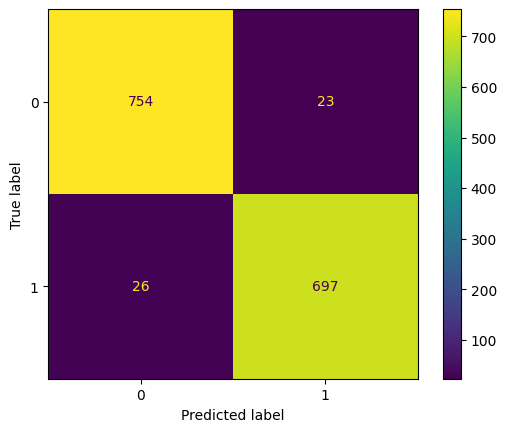

In [ ]:
# final model performance analysis
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score, precision_score, recall_score
from sklearn.metrics import ConfusionMatrixDisplay

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vit_model.eval()

vit_model = vit_model.to(device)

correct, total = 0, 0
all_preds, all_labels = [], []
with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc=f"Computing accuracy", unit="batch", leave=False):
        inputs, labels = inputs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        outputs = vit_model(inputs)
        probs = torch.sigmoid(outputs)
        predicted = torch.round(probs).squeeze()
        total += labels.shape[0]
        correct += (predicted == labels).sum().item()

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

y_true = np.array(all_labels)
y_pred = np.array(all_preds)

print("\nAccuracy:", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred))
print("Recall:", recall_score(y_true, y_pred))
print("F1 Score:", f1_score(y_true, y_pred))

cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(cm).plot()

print("\nClassification Report:")
print(classification_report(y_true, y_pred, digits=2))

In [ ]:
import pandas as pd

metrics = {
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Value":  [0.9673333333333334,
               0.9680555555555556,
               0.9640387275242047,
               0.966042966042966]
}

metrics_df = pd.DataFrame(metrics)
metrics_df


,Metric,Value
0,Accuracy,0.967333
1,Precision,0.968056
2,Recall,0.964039
3,F1 Score,0.966043


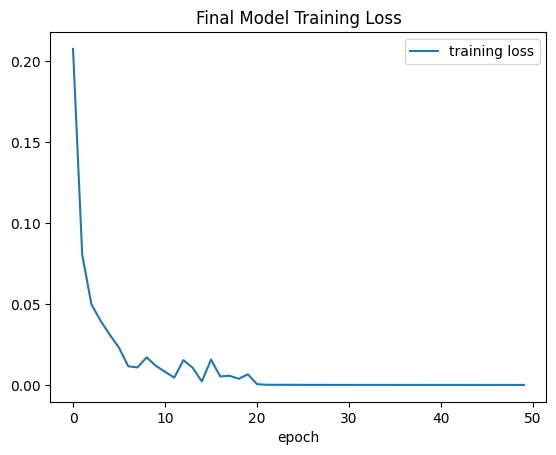

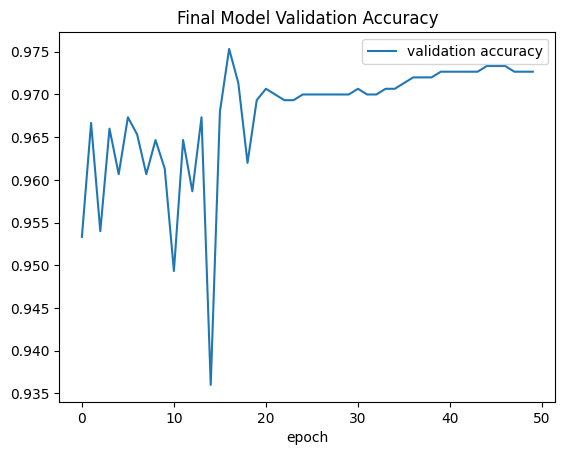

In [ ]:
# plot final model training curve
final_result = torch.load('final_result.pt')

plt.plot(final_result['train_loss'], label='training loss')
plt.xlabel('epoch')
plt.title('Final Model Training Loss')
plt.legend()
plt.show()

plt.plot(final_result['valid_accuracy'], label='validation accuracy')
plt.xlabel('epoch')
plt.title('Final Model Validation Accuracy')
plt.legend()
plt.show()

### 5. Qualitative results & implementation on new data

To provide **qualitative evidence** of model behaviour, we show random images from the test set with:

- their **ground‑truth label** (REAL / FAKE)
- the model's **predicted label**
- the predicted **probability of being FAKE**



In [ ]:
# load final model
vit_model = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)
vit_model.heads.head = nn.Sequential(
    nn.Dropout(dropout_rate),
    nn.Linear(vit_model.heads.head.in_features, 1)
)
vit_model.load_state_dict(torch.load("final_model_epoch_16"))

<All keys matched successfully>

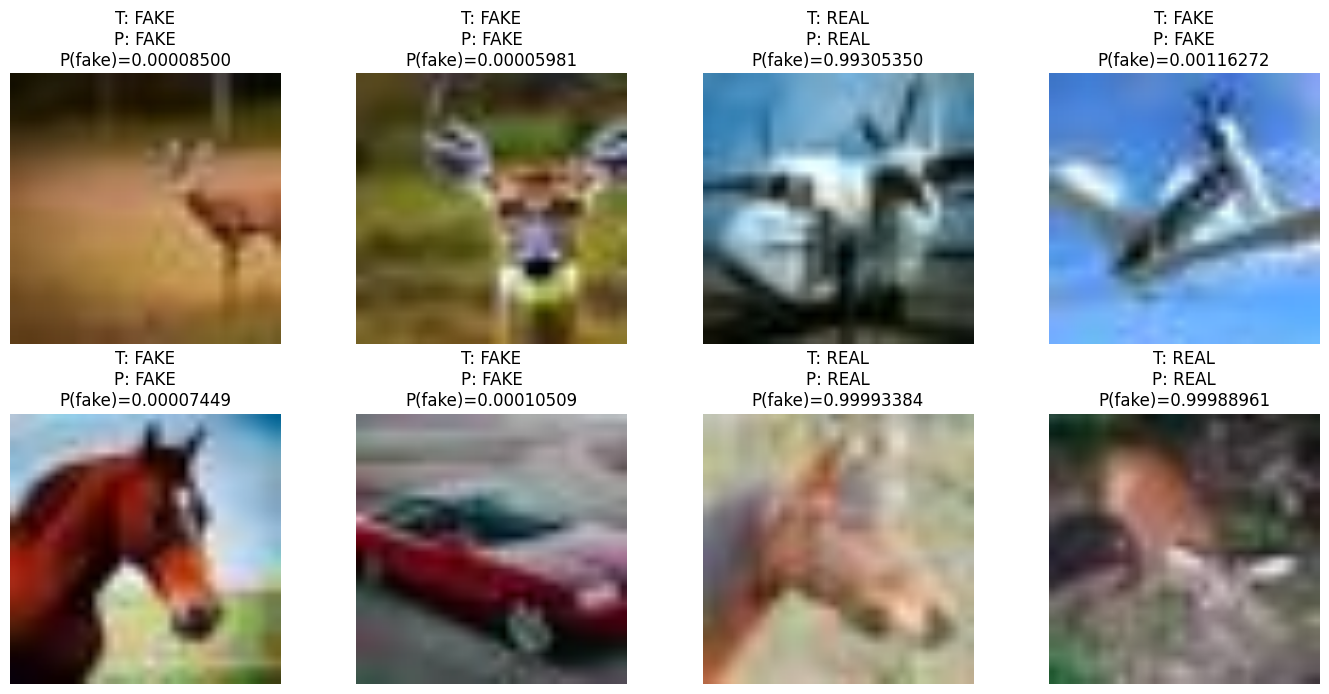

In [ ]:
# show random test images with predictions
import matplotlib.pyplot as plt
import numpy as np

class_names = {v: k for k, v in full_dataset.class_to_idx.items()}

def show_predictions(model, dataset, n_samples=8):
    model.eval()
    device = next(model.parameters()).device

    indices = np.random.choice(len(dataset), size=n_samples, replace=False)
    n_cols = 4
    n_rows = int(np.ceil(n_samples / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.5*n_cols, 3.5*n_rows))
    axes = axes.flatten()

    for ax, idx in zip(axes, indices):
        img, label = dataset[idx]
        input_tensor = img.unsqueeze(0).to(device)
        with torch.no_grad():
            output = model(input_tensor)
            prob_fake = torch.sigmoid(output).item()
            pred_label = int(round(prob_fake))
        # undo normalization
        mean_arr = np.array(mean).reshape(3, 1, 1)
        std_arr = np.array(std).reshape(3, 1, 1)
        img_np = img.numpy()
        img_np = (img_np * std_arr + mean_arr).clip(0, 1)
        img_np = np.transpose(img_np, (1, 2, 0))
        ax.imshow(img_np)
        ax.axis("off")
        true_name = class_names[label]
        pred_name = class_names[pred_label]
        ax.set_title(f"T: {true_name}\nP: {pred_name}\nP(fake)={prob_fake:.8f}")
    # if there are unused axes (when n_samples not multiple of n_cols)
    for ax in axes[len(indices):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

show_predictions(vit_model, test_dataset, n_samples=8)

### 6. Demonstration
Testing our model on new images randomly obtained from the internet

In [ ]:
# function to predict one image
def pred_one_image(image_path, model):
    transform = transforms.Compose([
        transforms.Resize((32, 32)),
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std)
    ])

    image = Image.open(image_path)
    image = transform(image).unsqueeze(0)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()

    model = model.to(device)
    with torch.no_grad():
        image = image.to(device, non_blocking=True)
        output = model(image)
        probs = torch.sigmoid(output)
        predicted = torch.round(probs).squeeze()

    # return probability and label
    return probs.item()*100, predicted.item()

In [ ]:
# load final model
vit_model = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)
vit_model.heads.head = nn.Sequential(
    nn.Dropout(dropout_rate),
    nn.Linear(vit_model.heads.head.in_features, 1)
)
vit_model.load_state_dict(torch.load("final_model_epoch_16"))

<All keys matched successfully>

image from google (spotpetinsurance.ca)
probability of image being real: 98.6418%


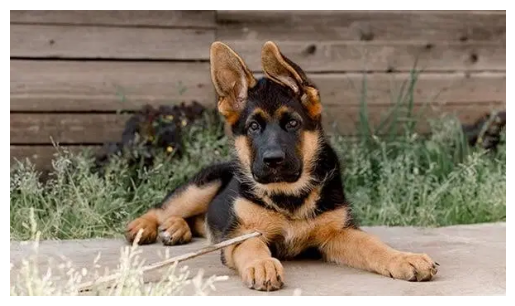

image generated by gemini
probability of image being real: 0.0221%


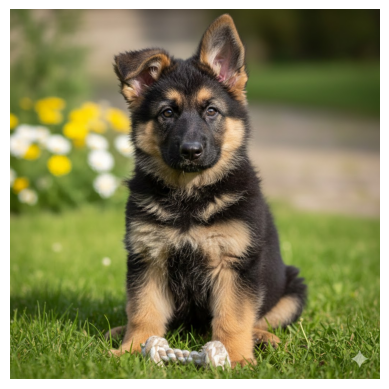

In [ ]:
# a real image
path_1 = "/content/image.webp"
print("image from google (spotpetinsurance.ca)")
print(f"probability of image being real: {round(pred_one_image(path_1, vit_model)[0], 4)}%")
image = Image.open(path_1).convert("RGB")
plt.imshow(image)
plt.axis("off")
plt.show()

# a fake image
path_2 = "/content/unnamed.jpg"
print("image generated by gemini")
print(f"probability of image being real: {round(pred_one_image(path_2, vit_model)[0], 4)}%")
image = Image.open(path_2).convert("RGB")
plt.imshow(image)
plt.axis("off")
plt.show()

## Part 3. Evaluation and Discussion

### 1. Results Evaluation


*   The model achieves 96.73% test accuracy on the CIFAKE dataset.
*   Confusion matrix shows balanced performance:

      REAL correctly predicted: 754

      FAKE correctly predicted: 697

      Misclassifications: 23 REAL → FAKE, 26 FAKE → REAL


*   Precision, recall, and F1-score for both classes are all around 0.96–0.97, indicating strong and consistent classification performance.
*   We have an interesting finding that directly connects to concepts discussed in class.
Our results show that Vision Transformers, through their global self-attention mechanism, are particularly effective at detecting AI-generated images. This aligns with the lecture idea that Transformers capture long-range dependencies instead of relying solely on local patterns. Because synthetic images often contain globally consistent textures or unrealistic regularities, the ViT-B/16 model can exploit these global relationships to distinguish REAL from FAKE images more effectively than a traditional CNN-based approach.




### 2. Related work (brief summary)



- **CIFAKE dataset and baseline CNNs** – Bird & Lotfi (2023) introduced the CIFAKE benchmark (120k images, 10 classes) for detecting AI‑generated images, and showed that standard CNNs such as ResNet‑50 can reach around **93% accuracy** on the REAL vs FAKE task using Grad‑CAM to interpret predictions [[Bird & Lotfi, 2023]](https://arxiv.org/abs/2303.14126).

- **CNN‑based CIFAKE classifiers and ensembles** – Follow‑up work compares deeper CNNs (e.g. DenseNet‑201, VGG‑19, ResNet‑101) on CIFAKE and related synthetic‑image datasets, reporting accuracies up to about **97%** with carefully tuned DenseNet‑201 models [[Akbar et al., 2025]](https://jurnalnasional.ump.ac.id/index.php/JUITA/article/view/25790). Meta‑ensembles such as **MEXFIC** combine several strong CNN backbones and reach roughly **94%** accuracy on CIFAKE while also providing Grad‑CAM visualizations for interpretability [[Islam et al., 2025]](https://doi.org/10.1016/j.aej.2024.12.031).

- **Transformer and hybrid models for AI‑generated images** – More recent papers move from pure CNNs to Vision Transformers and hybrid CNN+attention architectures. Edge‑enhanced ViT detectors that explicitly emphasize edge artefacts report CIFAKE accuracies in the **97–98%** range [[Das et al., 2025]](https://arxiv.org/abs/2508.17877), and ViT‑B/16‑style backbones fine‑tuned on domain‑specific AI‑image datasets (e.g. interior‑design images) achieve around **96%** accuracy in real‑vs‑fake classification [[Wang, 2025]](https://doi.org/10.31449/inf.v49i16.7979).

Our project is intentionally **simpler** and focused on **reproducibility and clarity**, rather than chasing state‑of‑the‑art numbers:

- We fine‑tune a single **ViT‑B/16** backbone on CIFAKE using standard transfer‑learning techniques.  
- We use **Optuna** to run a small but transparent hyper‑parameter search (learning rate, weight decay, batch size, dropout).  
- We evaluate on a fixed **train/validation/test split of CIFAKE** and report accuracy, confusion matrix and Grad‑CAM visualizations, so that classmates can easily reproduce our baseline and extend it with more advanced models (ensembles, larger transformers, or hybrid CNN+ViT architectures).

**Key references (for report)**

```text
[Bird & Lotfi, 2023] J. J. Bird and A. Lotfi. "CIFAKE: Image Classification and Explainable Identification of AI‑Generated Synthetic Images". arXiv:2303.14126 / IEEE Access, 2024.

[Akbar et al., 2025] A. F. Akbar et al. "Performance Analysis of Deep Learning Architectures in Classifying Fake and Real Images". JUITA, 2025.

[Islam et al., 2025] M. T. Islam et al. "MEXFIC: A Meta Ensemble eXplainable Approach for AI‑Synthesized Fake Image Classification". Alexandria Engineering Journal, 2025.

[Das et al., 2025] P. Das et al. "Edge‑Enhanced Vision Transformer Framework for Accurate AI‑Generated Image Detection". arXiv preprint, 2025.

[Wang, 2025] H. Wang. "Vision Transformer‑Based Framework for AI‑Generated Image Detection in Interior Design". Informatica, 2025.
```

### 3. Reproducibility


Several measure has been used in this project to ensure it is reproducible.
- a **global seed** of 123 has been set where all seeding in the project uses this seed.
- **generator** with a fixed manual_seed has been used in splitting datasets and dataloaders to ensure that randomness is reproducible.
- the Tree-structured Parzen Estimator **Sampler** in Optuna has also been seeded to ensure that hyperparameter optimization is deterministic, it will always start with the same choice of hyperparamter.  Also, we reset the seed at the beginning of each trial to ensure that randomness such as weight initialization of model is controlled.
- since we are working with a high number of parallel processes in the dataloader, and parallization often does not work well with reproducibility, we use a **seed_worker** function in the **worker_init_fn** of each dataloader to ensure each worker process is deterministic for different runs.
- after obtaining the best hyperparamter based on 50 trials, we run the final model in the exact same setting as during hyperparamter optimization to ensure the training process behaves exactly like during the hyperparamter optimization process.

### 4. Discussion & Insights

Optimization methods learned from the project
- **Automatic Mixed Precision** can allow use of both 16 bits and 32 bits floating point calculation. For example, 16 bits for forward pass and 32 bits for loss calculation. This can significantly speed up training, especially, during hyperparamter optimization.

- **Optuna** is a hyperparamter optimization framework that can find the best hyperparameter combination given a number of trials, using results from previou runs. It allow us to obtain better hyperparamters than fixed grid search or random search. To make our hyperparamter tuning efficient, we used a median pruner that aggresively prune underperforming trials, while also give good trials more epochs to train.

- **GPU** is one of the most important factor of faster training. The hyperparamter optimization process of this project was trained on the **Nvidia GH200 GPU**, with 95 GiB of GPU memory, and a 64 cores with 432 GiB RAM CPU. This allows us to run extremely high number of **num_workers** (32 for train and 16 for valid) and **prefetch_factor** (of 8) in the dataloader, which can have a higher number of parallel processes that feed data to the GPU. This significantly decreased training time.

Some key observations from our experiments

- **ViT transfer learning works well on CIFAKE.** Even with a relatively small number of epochs, the model can reach high validation and test accuracies, confirming that pre-trained ViTs are strong feature extractors even for 32×32 images upsampled to 224×224.

- **Hyperparameters matter.** We observed noticeable differences across trials in terms of learning curves and peak validation accuracy. Optuna helped us quickly identify a good region of the hyperparameter space.

- **Overfitting vs underfitting.** By comparing training loss and validation accuracy curves, we can see whether the model is overfitting (training loss ↓ while val accuracy plateaus or drops) or underfitting (both metrics stagnate). This can guide future changes such as stronger regularization, data augmentation or more training data.

- **Qualitative results are essential.** Looking at correctly and incorrectly classified examples helps us reason about **failure modes** (e.g., highly ambiguous images, heavy artifacts, or unusual compositions) and think about why the model is making mistakes.


### Possible next steps

If we had more time / resources, we could:

- Compare ViT with alternative backbones (ResNet, DenseNet, EfficientNet, AlexNet, Custom CNN).  
- Increase number of trials in Optuna for searching even better hyperparameter combinations.
- Add **explainability** via Grad-CAM, attention visualization or feature attribution methods.  
- Train on one subset (e.g., only FAKE images) and test on REAL (and vice‑versa) to study domain shift.  
- Extend the project to **other datasets** of AI-generated images and test generalization beyond CIFAKE.
- Train on images of higher resolution, for example, 224x224 pixles.

### Saving to html

In [8]:
#!pip install nbconvert

%%shell
jupyter nbconvert --to html /content/MIE1517_Project_team3.ipynb

[NbConvertApp] Converting notebook /content/MIE1517_Project_team3.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 9 image(s).
[NbConvertApp] Writing 3735446 bytes to /content/MIE1517_Project_team3.html
